# Deutsch's Algorithm

In [18]:
import qiskit
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [4]:
# Build the oracle gate: for f(x)=x it's simply a CNOT (control=input qubit, target=ancilla)
oracle = QuantumCircuit(2, name='U_f')
oracle.cx(0, 1)
U_f = oracle.to_gate()
U_f.label = 'U_f'

In [23]:
qc = QuantumCircuit(2, 1)
qc.h(0)  # Put input qubit in superposition
qc.x(1)  # Prepare ancilla in |1>
qc.h(1)  # Put ancilla in superposition
qc.append(U_f, [0, 1])  # Apply oracle
qc.h(0)  # Convert phase into amplitude on input qubit
qc.measure(0, 0) # Measure input qubit

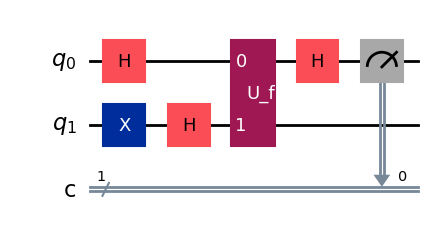

In [24]:
qc.draw('mpl')

Simulation counts for qc (phase oracle f(x)=x): {'1': 1000}


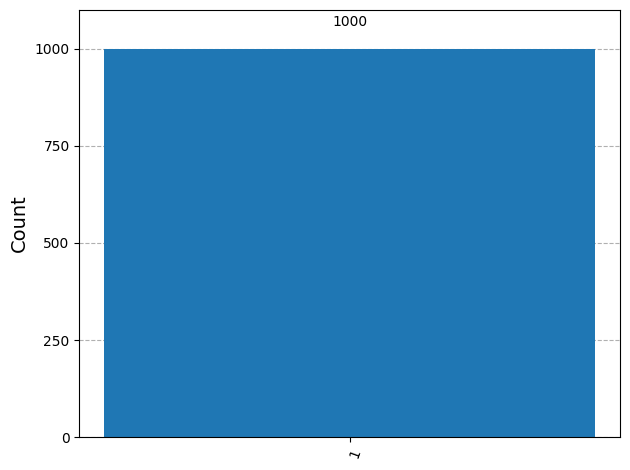

In [25]:
# Simulate
sim = AerSimulator()
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1000)
result = job.result()
counts = result.get_counts()

print('Simulation counts for qc (phase oracle f(x)=x):', counts)
plot_histogram(counts)